# Sprint 5 · Webinar 20 · Sesión Práctica  
## Caso: licores latinoamericanos

**Duración:** 100 minutos  
**Nivel:** principiante  
**Formato:** práctica guiada con ejercicios cortos y progresivos

### Objetivo general
Trabajar un dataset sencillo para practicar cuatro habilidades clave de análisis de datos con `pandas`:

1. **Tratamiento de nulos**
2. **Detección de outliers con IQR**
3. **Agrupaciones con `groupby()`**
4. **Gráficas básicas con `.plot()`**

> En esta versión del notebook los ejercicios están separados en bloques pequeños, con más explicación teórica y código más fácil de seguir.


## Ruta de la clase

### Estructura de la sesión
- **Ejercicio 0:** exploración inicial del dataset
- **Sección 1:** tratamiento de nulos
- **Sección 2:** detección de outliers con IQR
- **Sección 3:** análisis con `groupby()`
- **Sección 4:** visualización con `.plot()`
- **Cierre y take aways**

### Recomendación para la sesión
Ejecuta el notebook en orden.  
Cada sección reutiliza el resultado de la anterior:
- primero limpiamos,
- luego detectamos valores extremos,
- después resumimos,
- y por último graficamos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Preparación de un dataset sintético para la práctica
# ---------------------------------------------------------
# Si el archivo no existe, lo creamos. Así el notebook
# puede ejecutarse de forma autónoma en cualquier equipo.
# ---------------------------------------------------------

ruta = Path("licores_latam_practica.csv")

if not ruta.exists():
    rng = np.random.default_rng(42)
    n = 40

    df_base = pd.DataFrame({
        "product_id": range(1, n + 1),
        "country": rng.choice(["Colombia", "México", "Perú", "Chile", "Argentina"], size=n),
        "category": rng.choice(["Ron", "Pisco", "Tequila", "Vino", "Cerveza"], size=n),
        "brand": [f"Marca_{i+1:02d}" for i in range(n)],
        "abv_percent": rng.integers(4, 45, size=n).astype(float),
        "bottle_volume_ml": rng.choice([330, 355, 500, 700, 750, 1000], size=n).astype(float),
        "price_usd": np.clip(rng.normal(18, 7, size=n).round(2), 4, None),
        "rating": np.clip(rng.normal(4.1, 0.4, size=n).round(1), 2.8, 4.9),
        "export_volume_liters": rng.integers(800, 20000, size=n).astype(float)
    })

    # Insertamos algunos valores faltantes para practicar limpieza
    df_base.loc[[2, 5], "price_usd"] = np.nan
    df_base.loc[[9, 15], "rating"] = np.nan
    df_base.loc[22, "country"] = np.nan
    df_base.loc[30, "category"] = np.nan
    df_base.loc[7, "abv_percent"] = np.nan

    # Insertamos dos outliers en el precio
    df_base.loc[1, "price_usd"] = 95
    df_base.loc[27, "price_usd"] = 120

    df_base.to_csv(ruta, index=False)

print(f"Archivo listo para la clase: {ruta.resolve()}")

Archivo listo para la clase: /licores_latam_practica.csv


## Ejercicio 0 · Exploración inicial del dataset

**Objetivo:** familiarizarnos con el caso de estudio antes de limpiar o analizar.

### ¿Qué vamos a hacer?
Primero cargaremos el archivo y observaremos sus primeras filas.  
La idea es reconocer:
- qué representa cada columna,
- cuáles son numéricas,
- cuáles son categóricas,
- y dónde podrían aparecer problemas de calidad.

### Pista
Antes de limpiar un dataset, conviene entender su estructura.


In [2]:
df = pd.read_csv(ruta)

df.head()

,product_id,country,category,brand,abv_percent,bottle_volume_ml,price_usd,rating,export_volume_liters
0,1,Colombia,Ron,Marca_01,42.0,500.0,22.38,4.7,12601.0
1,2,Chile,Vino,Marca_02,21.0,750.0,95.00,4.0,18387.0
2,3,Chile,Vino,Marca_03,10.0,700.0,NaN,3.7,19522.0
3,4,Perú,Pisco,Marca_04,38.0,500.0,13.37,4.2,5220.0
4,5,Perú,Ron,Marca_05,29.0,1000.0,15.46,4.2,5339.0


### Preguntas guiadas
- ¿Qué columnas parecen numéricas?
- ¿Qué columnas describen categorías o texto?
- ¿Qué variable te parece más útil para detectar outliers?
- ¿Qué columnas crees que podrían servir para hacer agrupaciones?


# Sección 1 · Tratamiento de nulos

Los **valores nulos** o faltantes aparecen cuando una observación no tiene dato registrado.  
En análisis de datos esto es muy importante porque puede afectar:
- promedios,
- conteos,
- visualizaciones,
- y decisiones de negocio.

## Estrategias básicas frente a nulos
1. **Detectarlos**
2. **Explorarlos**
3. **Eliminarlos** con `dropna()`
4. **Imputarlos** con un valor razonable

## ¿Cuándo usar cada una?
- **Eliminar filas** puede servir si son pocas o si faltan datos clave.
- **Media** se usa cuando la variable es numérica y no tiene valores extremos fuertes.
- **Mediana** suele ser mejor cuando hay outliers.
- **Moda** es útil para columnas categóricas.


## Ejercicio 1 · Contar valores faltantes

**Objetivo:** identificar cuántos nulos hay por columna.

### Explicación
`isna()` convierte cada celda en `True` o `False` según esté vacía o no.  
Luego, `sum()` cuenta cuántos `True` hay en cada columna.

### Pista
Usa `df.isna().sum()`.


In [3]:
df.isna().sum()

product_id              0
country                 1
category                1
brand                   0
abv_percent             1
bottle_volume_ml        0
price_usd               2
rating                  2
export_volume_liters    0
dtype: int64

## Ejercicio 2 · Ver las filas que tienen al menos un nulo

**Objetivo:** inspeccionar qué registros están incompletos.

### Explicación
A veces no basta con contar nulos: también necesitamos ver **en qué filas** aparecen.

### Pista
Puedes usar `df.isna().any(axis=1)` para quedarte con filas que tengan al menos un valor faltante.


In [4]:
filas_con_nulos = df[df.isna().any(axis=1)]

filas_con_nulos

,product_id,country,category,brand,abv_percent,bottle_volume_ml,price_usd,rating,export_volume_liters
2,3,Chile,Vino,Marca_03,10.0,700.0,NaN,3.7,19522.0
5,6,Argentina,Cerveza,Marca_06,32.0,700.0,NaN,4.6,1518.0
7,8,Chile,Cerveza,Marca_08,NaN,750.0,21.41,4.2,11453.0
9,10,Colombia,Vino,Marca_10,38.0,700.0,18.09,NaN,7921.0
15,16,Chile,Ron,Marca_16,15.0,355.0,17.44,NaN,6889.0
22,23,NaN,Pisco,Marca_23,37.0,355.0,15.35,4.3,18186.0
30,31,Perú,NaN,Marca_31,15.0,1000.0,23.88,4.5,6536.0


## Ejercicio 3 · Primer acercamiento con `dropna()`

**Objetivo:** entender qué pasa si eliminamos todas las filas con algún nulo.

### Explicación
`dropna()` elimina filas incompletas.  
Es una solución rápida, pero puede borrar demasiados datos.

### Pregunta importante
¿Vale la pena perder información o es mejor imputar?

### Pista
Compara el tamaño original del dataset con el tamaño después de `dropna()`.


In [5]:
df_drop_total = df.dropna()

print("Filas originales:", df.shape[0])
print("Filas después de dropna():", df_drop_total.shape[0])

Filas originales: 40
Filas después de dropna(): 33


## Ejercicio 4 · `dropna()` solo en columnas clave

**Objetivo:** aplicar una eliminación más controlada.

### Explicación
A veces una fila solo debe eliminarse si falta una columna realmente importante.  
En este caso, probaremos con `country` y `category`.

### Pista
Usa el parámetro `subset=`.


In [6]:
df_drop_subset = df.dropna(subset=["country", "category"])

print("Filas originales:", df.shape[0])
print("Filas después de dropna(subset=['country', 'category']):", df_drop_subset.shape[0])

Filas originales: 40
Filas después de dropna(subset=['country', 'category']): 38


## Ejercicio 5 · Imputación numérica con media y mediana

**Objetivo:** comparar dos formas clásicas de imputar datos numéricos.

### Explicación teórica
- La **media** usa el promedio de la columna.
- La **mediana** usa el valor central una vez ordenados los datos.

Cuando hay outliers, la mediana suele ser una opción más estable.  
Como en este dataset hay precios muy altos, es una buena idea comparar ambas.

### Pista
Haz una copia del dataset para no modificar el original todavía.


In [7]:
df_media = df.copy()
df_mediana = df.copy()

media_precio = df["price_usd"].mean()
mediana_precio = df["price_usd"].median()

df_media["price_usd"] = df_media["price_usd"].fillna(media_precio)
df_mediana["price_usd"] = df_mediana["price_usd"].fillna(mediana_precio)

print("Media de price_usd:", round(media_precio, 2))
print("Mediana de price_usd:", round(mediana_precio, 2))

Media de price_usd: 20.88
Mediana de price_usd: 16.47


## Ejercicio 6 · Imputación final del dataset de trabajo

**Objetivo:** construir una versión limpia para seguir con la clase.

### Estrategia elegida
- `country` y `category`: imputación con **moda**
- `price_usd` y `rating`: imputación con **mediana**
- `abv_percent`: imputación con **media**

### ¿Por qué esta combinación?
Porque mezcla una lógica sencilla y pedagógica:
- **moda** para texto/categorías,
- **mediana** para variables numéricas sensibles a outliers,
- **media** para una variable numérica continua como `abv_percent`.

### Pista
Usa `mode()[0]`, `median()` y `mean()`.


In [8]:
df_limpio = df.copy()

moda_country = df_limpio["country"].mode()[0]
moda_category = df_limpio["category"].mode()[0]
mediana_price = df_limpio["price_usd"].median()
mediana_rating = df_limpio["rating"].median()
media_abv = df_limpio["abv_percent"].mean()

df_limpio["country"] = df_limpio["country"].fillna(moda_country)
df_limpio["category"] = df_limpio["category"].fillna(moda_category)
df_limpio["price_usd"] = df_limpio["price_usd"].fillna(mediana_price)
df_limpio["rating"] = df_limpio["rating"].fillna(mediana_rating)
df_limpio["abv_percent"] = df_limpio["abv_percent"].fillna(media_abv)

df_limpio.isna().sum()

product_id              0
country                 0
category                0
brand                   0
abv_percent             0
bottle_volume_ml        0
price_usd               0
rating                  0
export_volume_liters    0
dtype: int64

### Mini-análisis de la Sección 1
- ¿Qué estrategia te pareció más agresiva: `dropna()` o imputar?
- ¿En qué caso usarías mediana en lugar de media?
- ¿Qué riesgo existe si imputamos demasiados datos sin revisar el contexto?


# Sección 2 · Outliers con IQR

Un **outlier** es un valor que se aleja mucho del comportamiento general de los datos.  
No siempre es un error, pero sí merece revisión.

## Método IQR
El método del **rango intercuartílico** usa:
- **Q1:** percentil 25
- **Q3:** percentil 75
- **IQR = Q3 - Q1**

Luego definimos dos límites:
- **Límite inferior = Q1 - 1.5 × IQR**
- **Límite superior = Q3 + 1.5 × IQR**

Todo valor fuera de ese rango puede considerarse outlier.


## Ejercicio 7 · Calcular Q1, Q3 e IQR en `price_usd`

**Objetivo:** construir la base matemática para detectar outliers.

### Pista
Usa `quantile(0.25)` y `quantile(0.75)`.


In [9]:
Q1 = df_limpio["price_usd"].quantile(0.25)
Q3 = df_limpio["price_usd"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Límite inferior:", round(limite_inferior, 2))
print("Límite superior:", round(limite_superior, 2))

Q1: 12.94
Q3: 21.06
IQR: 8.12
Límite inferior: 0.76
Límite superior: 33.24


## Ejercicio 8 · Identificar los outliers

**Objetivo:** ver cuáles productos tienen un precio fuera del rango esperado.

### Explicación
Creamos una condición booleana y filtramos el dataset.

### Pista
Combina dos condiciones con `|`.


In [10]:
es_outlier = (df_limpio["price_usd"] < limite_inferior) | (df_limpio["price_usd"] > limite_superior)

outliers_precio = df_limpio[es_outlier]

outliers_precio[["product_id", "country", "category", "price_usd"]]

,product_id,country,category,price_usd
1,2,Chile,Vino,95.0
27,28,Argentina,Pisco,120.0


## Ejercicio 9 · Crear una versión sin outliers

**Objetivo:** preparar el dataset para análisis más estables.

### Explicación
En una clase introductoria, una estrategia simple es quitar temporalmente los outliers y seguir analizando.

> En proyectos reales también podríamos:
> - investigarlos,
> - corregirlos,
> - o conservarlos si representan un fenómeno real.

### Pista
Usa `~es_outlier`.


In [11]:
df_sin_outliers = df_limpio[~es_outlier].copy()

print("Filas con outliers eliminadas:", df_limpio.shape[0] - df_sin_outliers.shape[0])
print("Tamaño final del dataset:", df_sin_outliers.shape)

Filas con outliers eliminadas: 2
Tamaño final del dataset: (38, 9)


### Mini-análisis de la Sección 2
- ¿Cuántos outliers aparecieron?
- ¿Crees que esos valores son errores o productos premium?
- ¿Qué podría pasar con el promedio del precio si dejamos esos valores extremos?


# Sección 3 · GroupBy

`groupby()` sirve para **agrupar datos** y luego resumirlos.  
Es una de las herramientas más importantes de `pandas`.

## Idea general
Primero agrupamos por una categoría, por ejemplo `country`, y después aplicamos una operación:
- `count()`
- `mean()`
- `sum()`
- `max()`
- `min()`

## Estructura mental
**Agrupar + resumir**


## Ejercicio 10 · Contar productos por país

**Objetivo:** hacer un primer `groupby()` muy simple.

### Explicación
Vamos a contar cuántos registros tiene cada país.

### Pista
Agrupa por `country` y cuenta `product_id`.


In [12]:
productos_por_pais = df_sin_outliers.groupby("country")["product_id"].count().sort_values(ascending=False)

productos_por_pais

country
Perú         12
Chile         9
Argentina     7
Colombia      6
México        4
Name: product_id, dtype: int64

## Ejercicio 11 · Precio promedio por categoría

**Objetivo:** usar `groupby()` con una métrica de promedio.

### Explicación
Aquí queremos responder:  
**¿qué categoría tiene, en promedio, mayor precio?**

### Pista
Agrupa por `category` y usa `mean()`.


In [13]:
precio_promedio_categoria = df_sin_outliers.groupby("category")["price_usd"].mean().round(2).sort_values(ascending=False)

precio_promedio_categoria

category
Cerveza    19.45
Pisco      17.89
Vino       15.79
Ron        15.15
Tequila    14.21
Name: price_usd, dtype: float64

## Ejercicio 12 · Dos variables numéricas resumidas por país

**Objetivo:** comparar el precio promedio y el ABV promedio en una sola tabla.

### Explicación
Esta vez agrupamos por `country`, pero resumimos dos columnas numéricas al mismo tiempo.

### Pista
Selecciona dos columnas entre doble corchete `[[ ]]`.


In [14]:
resumen_pais = df_sin_outliers.groupby("country")[["price_usd", "abv_percent"]].mean().round(2)

resumen_pais

,price_usd,abv_percent
country,,
Argentina,17.15,20.00
Chile,18.57,25.22
Colombia,14.48,28.50
México,12.98,24.25
Perú,15.46,26.00


### Mini-análisis de la Sección 3
- ¿Qué país tiene más productos en el dataset?
- ¿Qué categoría muestra mayor precio promedio?
- ¿Observas alguna relación aparente entre precio promedio y graduación alcohólica?


# Sección 4 · Gráficas con `.plot()`

En `pandas`, `.plot()` permite crear visualizaciones rápidas sin escribir mucho código.  
Es ideal para una primera exploración.

## Tipos que usaremos
- `kind="bar"` → barras
- `kind="hist"` → histograma
- `kind="box"` → boxplot
- `kind="scatter"` → dispersión

> Recuerda: una gráfica debe responder una pregunta concreta.


## Ejercicio 13 · Gráfica de barras

**Objetivo:** visualizar el precio promedio por país.

### Pregunta analítica
¿Cuál es el país con mayor precio promedio?

### Pista
Primero crea un resumen con `groupby()`, luego aplica `.plot(kind="bar")`.


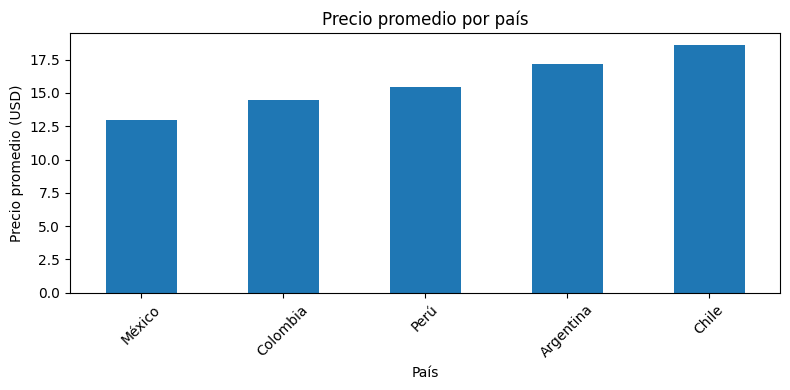

In [15]:
precio_promedio_pais = df_sin_outliers.groupby("country")["price_usd"].mean().sort_values()

ax = precio_promedio_pais.plot(kind="bar", figsize=(8, 4), title="Precio promedio por país")
ax.set_xlabel("País")
ax.set_ylabel("Precio promedio (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Ejercicio 14 · Histograma

**Objetivo:** observar cómo se distribuye `price_usd`.

### Explicación
El histograma nos ayuda a ver si la variable se concentra en ciertos rangos.

### Pista
Usa la columna numérica directamente y `kind="hist"`.


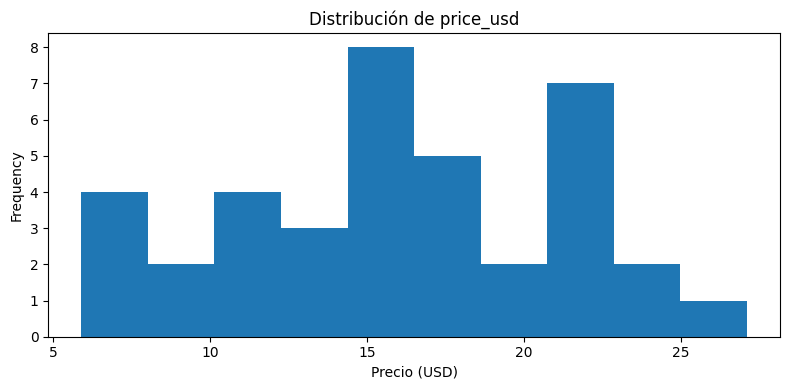

In [16]:
ax = df_sin_outliers["price_usd"].plot(kind="hist", bins=10, figsize=(8, 4), title="Distribución de price_usd")
ax.set_xlabel("Precio (USD)")
plt.tight_layout()
plt.show()

## Ejercicio 15 · Boxplot

**Objetivo:** revisar la dispersión del precio y detectar posibles extremos.

### Explicación
El boxplot resume una variable con:
- mediana,
- cuartiles,
- y posibles valores atípicos.

### Pista
Convierte la columna en un DataFrame con doble corchete.


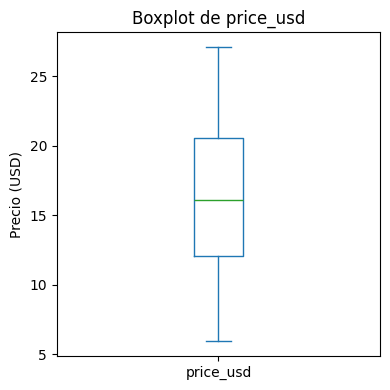

In [17]:
ax = df_sin_outliers[["price_usd"]].plot(kind="box", figsize=(4, 4), title="Boxplot de price_usd")
ax.set_ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

## Ejercicio 16 · Gráfico de dispersión

**Objetivo:** comparar `abv_percent` con `price_usd`.

### Pregunta analítica
¿Los productos con más graduación alcohólica tienden a ser más caros?

### Pista
Usa `kind="scatter"` e indica qué columna va en `x` y cuál en `y`.


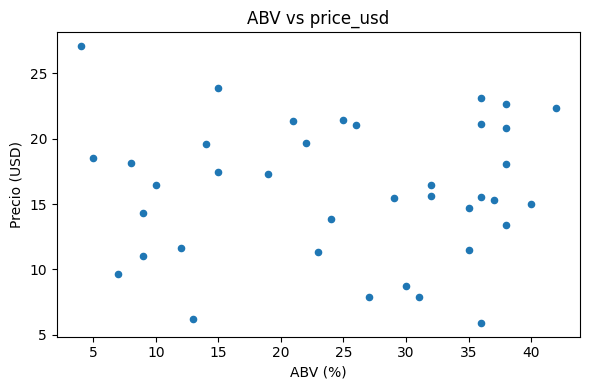

In [18]:
ax = df_sin_outliers.plot(
    kind="scatter",
    x="abv_percent",
    y="price_usd",
    figsize=(6, 4),
    title="ABV vs price_usd"
)

ax.set_xlabel("ABV (%)")
ax.set_ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

## Take aways

1. **Los nulos no se corrigen de una sola manera.**  
   Primero se detectan, luego se analiza si conviene eliminar o imputar.

2. **La mediana es muy útil cuando hay valores extremos.**  
   Por eso fue una buena opción para `price_usd`.

3. **El método IQR permite detectar outliers de forma sencilla.**  
   Es una técnica clásica, clara y muy apropiada para una primera práctica.

4. **`groupby()` resume información rápidamente.**  
   Con pocas líneas podemos comparar países, categorías y métricas.

5. **`.plot()` ayuda a convertir tablas en hallazgos visuales.**  
   Una buena gráfica hace más fácil interpretar los resultados.


## Cierre

### Lo que logramos hoy
- Exploramos un dataset realista y pequeño
- Detectamos y tratamos valores faltantes
- Identificamos outliers con IQR
- Resumimos información con `groupby()`
- Creamos visualizaciones sencillas con `.plot()`

### Actividad sugerida de repaso
1. Cambia la variable analizada en la sección de outliers y prueba con `abv_percent`.
2. Crea un `groupby()` por `category` y resume `export_volume_liters`.
3. Haz una nueva gráfica de barras con el total exportado por país.

### ¿Necesitas ayuda?
Recuerda los canales de ayuda que tenemos disponibles:
- `DATA-CO-LEARNING`: Revisa los horarios de atencion en la guia dele studiante. Recuerda que tenemos horarios de apoyo todos los días para tus dudas puntuales!
- `DA_CONSULTA`: Uuedes publicar tus preguntas sobre el contenido de la plataforma o el proyecto 24/7. Recuerda que en tu pregunta debes de agregar el tag @Dataconsulta.
- `SPRINT FOCUS`: Para los Sprints 1 al 5 tenemos sesiones extra donde abordamos temáticas de cada sprint a rpofundidad. Revisa la guia del estudiante para conocer los horarios!
- `SESIONES 1:1`: Recuerda que puedes agendar sesiones 1:1 con un tutor. Agendalas con antelación y resuelve todas tus dudas, desde temás del proyecto, curso, carrera hasta problemas técnicos.
- `CANAL DE DISCORD DE COMMUNITY`: Recuerda que tu cohorte tiene un canal especial donde puedes compartir cualquier item interesante que quieras mostrar a tus compañeros de curso.

### Siguiente paso
En una próxima clase, este mismo flujo puede extenderse a:
- análisis más profundo,
- comparación entre grupos,
- y construcción de dashboards.
